In [1]:
from CRNs import *
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_width_seed_big/"

var1_list = [1, 2, 3, 4, 5]  # e.g., proj_dim / NR
var2_list = [1, 2, 3, 4, 5]  # e.g., hidden_dim
var3_list = [1, 2, 3, 4, 5]  # seeds (will average over these)

# Store results: var1 x var2, averaged over var3
accuracy_matrix = np.zeros((len(var1_list), len(var2_list)))
loss_matrix = np.zeros((len(var1_list), len(var2_list)))

for i, var1 in enumerate(var1_list):
    for j, var2 in enumerate(var2_list):
        accuracies = []
        losses = []
        
        for var3 in var3_list:
            file = path + f"{var1}_{var2}_{var3}/training_results.pkl"
            try:
                with open(file, "rb") as f:
                    data = pickle.load(f)
                
                history = data['history']
                
                # Get final accuracy (average of last 100 batches)
                if hasattr(history, 'get_recent_avg'):
                    final_acc = history.get_recent_avg('accuracy', window=100)
                    final_loss = history.get_recent_avg('loss', window=100)
                else:
                    # Fallback if history is a dict
                    final_acc = np.mean(history.accuracy_history[-100:])
                    final_loss = np.mean(history.loss_history[-100:])
                
                accuracies.append(final_acc)
                losses.append(final_loss)
                
            except FileNotFoundError:
                print(f"File not found: {file}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
        
        # Average over seeds
        if accuracies:
            accuracy_matrix[i, j] = np.mean(accuracies)
            loss_matrix[i, j] = np.mean(losses)
        else:
            accuracy_matrix[i, j] = np.nan
            loss_matrix[i, j] = np.nan



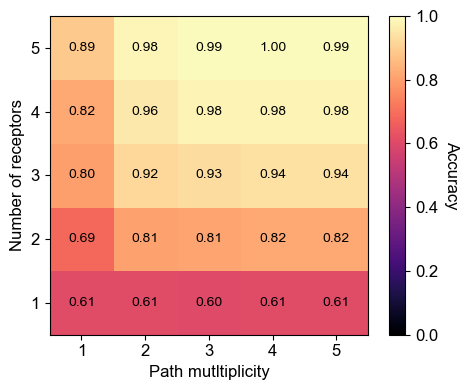


Accuracy Matrix (rows=var1, cols=var2, averaged over var3):
[[0.60784 0.60904 0.60448 0.60832 0.60712]
 [0.6852  0.80688 0.81128 0.8172  0.8184 ]
 [0.79776 0.92168 0.93208 0.94136 0.94072]
 [0.82    0.95656 0.97952 0.97784 0.97928]
 [0.8868  0.98384 0.99264 0.99576 0.99416]]


In [8]:
# Plot heatmap
import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

import numpy as np
fs = 12
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Accuracy heatmap
im1 = ax.imshow(accuracy_matrix, cmap='magma', vmin=0.0, vmax=1, origin='lower')
ax.set_xticks(range(len(var2_list)))
ax.set_xticklabels(var2_list, fontsize=fs)
ax.set_yticks(range(len(var1_list)))
ax.set_yticklabels(var1_list, fontsize=fs)
ax.set_xlabel('Path mutltiplicity', fontsize=fs)
ax.set_ylabel('Number of receptors', fontsize=fs)

cbar = plt.colorbar(im1, ax=ax)
cbar.ax.set_ylabel('Accuracy', rotation=-90, va="bottom", fontsize=fs)
cbar.ax.tick_params(labelsize=fs)

# Add text annotations
for i in range(len(var1_list)):
    for j in range(len(var2_list)):
        val = accuracy_matrix[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=text_color, fontsize=fs-2)

plt.tight_layout()
plt.show()

# Print summary table
print("\nAccuracy Matrix (rows=var1, cols=var2, averaged over var3):")
print(accuracy_matrix)

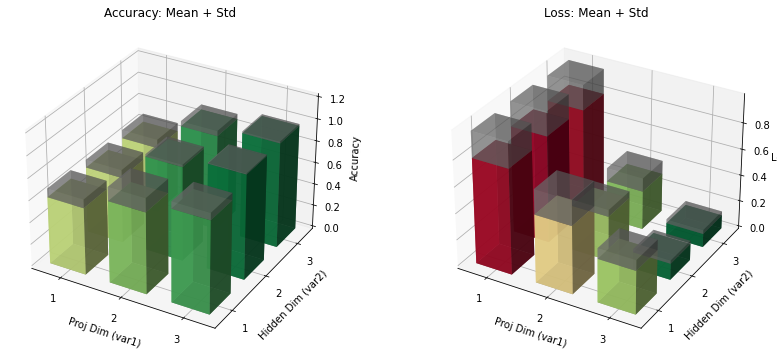


Accuracy Std Matrix:
[[0.07710795 0.06972428 0.07616847]
 [0.12485483 0.02117609 0.04677815]
 [0.06421409 0.01028137 0.01626557]]

Loss Std Matrix:
[[0.19795537 0.18507063 0.19082743]
 [0.18851328 0.05170811 0.10257356]
 [0.07946465 0.02494417 0.03076971]]


In [28]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_width_seed2/"

var1_list = [1, 2, 3]  # e.g., proj_dim / NR
var2_list = [1, 2, 3]  # e.g., hidden_dim
var3_list = [1, 2, 3]  # seeds

# Store results
accuracy_matrix = np.zeros((len(var1_list), len(var2_list)))
accuracy_std_matrix = np.zeros((len(var1_list), len(var2_list)))
loss_matrix = np.zeros((len(var1_list), len(var2_list)))
loss_std_matrix = np.zeros((len(var1_list), len(var2_list)))

for i, var1 in enumerate(var1_list):
    for j, var2 in enumerate(var2_list):
        accuracies = []
        losses = []
        
        for var3 in var3_list:
            file = path + f"{var1}_{var2}_{var3}/training_results.pkl"
            try:
                with open(file, "rb") as f:
                    data = pickle.load(f)
                
                history = data['history']
                
                if hasattr(history, 'get_recent_avg'):
                    final_acc = history.get_recent_avg('accuracy', window=100)
                    final_loss = history.get_recent_avg('loss', window=100)
                else:
                    final_acc = np.mean(history.accuracy_history[-100:])
                    final_loss = np.mean(history.loss_history[-100:])
                
                accuracies.append(final_acc)
                losses.append(final_loss)
                
            except Exception as e:
                print(f"Error loading {file}: {e}")
        
        if accuracies:
            accuracy_matrix[i, j] = np.mean(accuracies)
            accuracy_std_matrix[i, j] = np.std(accuracies)
            loss_matrix[i, j] = np.mean(losses)
            loss_std_matrix[i, j] = np.std(losses)

# Create 3D bar plots
fig = plt.figure(figsize=(14, 6))

# Prepare grid positions
x_pos, y_pos = np.meshgrid(np.arange(len(var1_list)), np.arange(len(var2_list)))
x_pos = x_pos.flatten()
y_pos = y_pos.flatten()
z_pos = np.zeros_like(x_pos)

dx = dy = 0.6  # Bar width

# ===== Accuracy 3D bar plot =====
ax1 = fig.add_subplot(121, projection='3d')

# Mean bars
mean_vals = accuracy_matrix.T.flatten()
colors = plt.cm.RdYlGn(mean_vals)  # Color by accuracy value
ax1.bar3d(x_pos, y_pos, z_pos, dx, dy, mean_vals, color=colors, alpha=0.8, label='Mean')

# Std bars (stacked on top, different color)
std_vals = accuracy_std_matrix.T.flatten()
ax1.bar3d(x_pos, y_pos, mean_vals, dx, dy, std_vals, color='gray', alpha=0.5, label='Std')

ax1.set_xticks(np.arange(len(var1_list)) + dx/2)
ax1.set_xticklabels(var1_list)
ax1.set_yticks(np.arange(len(var2_list)) + dy/2)
ax1.set_yticklabels(var2_list)
ax1.set_xlabel('Proj Dim (var1)')
ax1.set_ylabel('Hidden Dim (var2)')
ax1.set_zlabel('Accuracy')
ax1.set_title('Accuracy: Mean + Std')
ax1.set_zlim(0, 1.2)

# ===== Loss 3D bar plot =====
ax2 = fig.add_subplot(122, projection='3d')

mean_vals = loss_matrix.T.flatten()
std_vals = loss_std_matrix.T.flatten()

# Normalize for coloring (low loss = green)
norm_vals = 1 - (mean_vals - mean_vals.min()) / (mean_vals.max() - mean_vals.min() + 1e-8)
colors = plt.cm.RdYlGn(norm_vals)

ax2.bar3d(x_pos, y_pos, z_pos, dx, dy, mean_vals, color=colors, alpha=0.8)
ax2.bar3d(x_pos, y_pos, mean_vals, dx, dy, std_vals, color='gray', alpha=0.5)

ax2.set_xticks(np.arange(len(var1_list)) + dx/2)
ax2.set_xticklabels(var1_list)
ax2.set_yticks(np.arange(len(var2_list)) + dy/2)
ax2.set_yticklabels(var2_list)
ax2.set_xlabel('Proj Dim (var1)')
ax2.set_ylabel('Hidden Dim (var2)')
ax2.set_zlabel('Loss')
ax2.set_title('Loss: Mean + Std')

plt.tight_layout()
plt.show()

# Print std summary
print("\nAccuracy Std Matrix:")
print(accuracy_std_matrix)
print("\nLoss Std Matrix:")
print(loss_std_matrix)

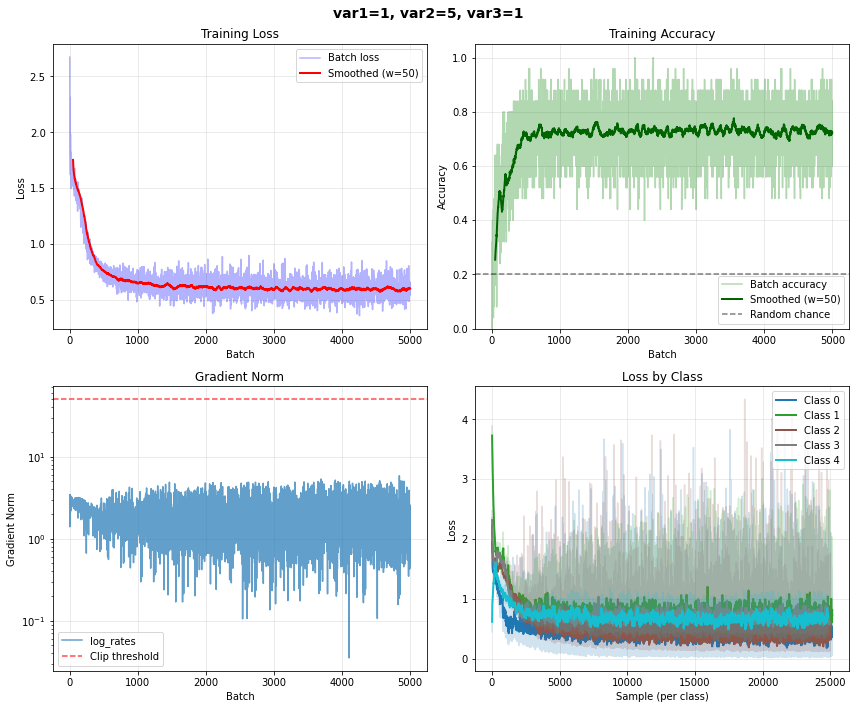

KeyError: 'log_means'

In [13]:
# Choose specific values
var1, var2, var3 = 1, 5, 1  # Example: proj_dim=2, hidden_dim=3, seed=1

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/NR_width_seed_big/"
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/tasks_width_seed2/"
file = path + f"{var1}_{var2}_{var3}/training_results.pkl"

with open(file, "rb") as f:
    data = pickle.load(f)

history = data['history']

plot_training_diagnostics(
    history, 
    title=f"var1={var1}, var2={var2}, var3={var3}",
    max_grad_norm=data.get('max_grad_norm', 50.0)
)

# Regenerate data from saved parameters
log_means = data['log_means']
n_classes = data['n_classes']
input_dim = data['input_dim']
log_variance = data['log_variance'] / input_dim  # per-dim variance
proj_dim = data['proj_dim']

_, data_list = generate_lognormal_mixture(
    n_classes=n_classes,
    n_samples_per_class=1000,  # Fewer for plotting
    input_dim=input_dim,
    log_means=log_means,
    log_variances=[log_variance] * n_classes,
    random_state=42
)
data_list = project_data_list(data_list, d=proj_dim)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear scale
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    axes[0].scatter(arr[:, 0], arr[:, 1], alpha=0.3, s=5, label=f'Class {c}')
axes[0].set_xlabel('Dim 1')
axes[0].set_ylabel('Dim 2')
axes[0].set_title(f'Linear Scale (var1={var1}, var2={var2}, var3={var3})')
axes[0].legend()

# Log scale
for c, class_data in enumerate(data_list):
    arr = np.vstack(class_data)
    axes[1].scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=5, label=f'Class {c}')
# Plot centers
for i, lm in enumerate(log_means):
    axes[1].scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
axes[1].set_xlabel('log(Dim 1)')
axes[1].set_ylabel('log(Dim 2)')
axes[1].set_title('Log Scale (Gaussian clusters)')
axes[1].legend()

plt.tight_layout()
plt.show()

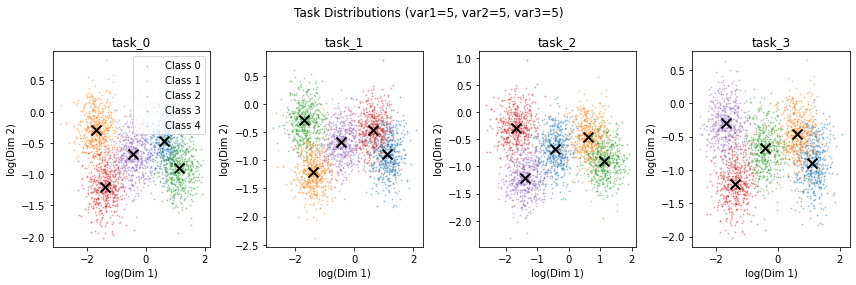

In [22]:
# ============== VISUALIZE TASK DATA ==============
task_data = data['task_data']
n_tasks = data['n_tasks']
n_classes = data['n_classes']
input_dim = data['input_dim']
proj_dim = data['proj_dim']
log_variance = data['log_variance'] / input_dim  # per-dim variance

task_ids = list(task_data.keys())

fig, axes = plt.subplots(1, min(n_tasks, 4), figsize=(12, 4))
if n_tasks == 1:
    axes = [axes]

for i, task_id in enumerate(task_ids[:4]):
    task = task_data[task_id]
    log_means = task['log_means']
    
    # Regenerate data from log_means
    _, data_list = generate_lognormal_mixture(
        n_classes=n_classes,
        n_samples_per_class=500,
        input_dim=input_dim,
        log_means=log_means,
        log_variances=[log_variance] * n_classes,
        random_state=42
    )
    data_list = project_data_list(data_list, d=proj_dim)
    
    ax = axes[i]
    for c, class_data in enumerate(data_list):
        arr = np.vstack(class_data)
        ax.scatter(np.log(arr[:, 0]), np.log(arr[:, 1]), alpha=0.3, s=1, label=f'Class {c}')
    
    # Plot centers
    for lm in log_means:
        ax.scatter(lm[0], lm[1], marker='x', s=100, c='black', linewidths=2)
    
    ax.set_xlabel('log(Dim 1)')
    ax.set_ylabel('log(Dim 2)')
    ax.set_title(f'{task_id}')
    if i == 0:
        ax.legend()

plt.suptitle(f'Task Distributions (var1={var1}, var2={var2}, var3={var3})')
plt.tight_layout()
plt.show()

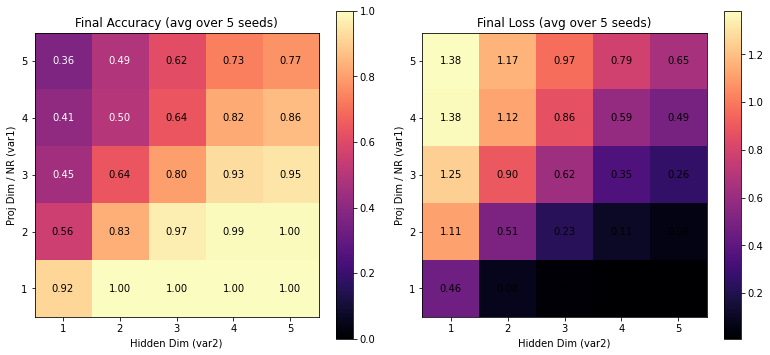


Accuracy Matrix (rows=var1, cols=var2, averaged over var3):
[[0.91584 0.99832 0.99888 0.9992  0.99944]
 [0.55728 0.83304 0.9676  0.99448 0.99576]
 [0.45008 0.63904 0.79928 0.93344 0.94624]
 [0.40744 0.49728 0.6404  0.82072 0.86288]
 [0.36448 0.48984 0.61512 0.73376 0.7748 ]]


In [21]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# Set up parameters and data
path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Dirs/Training/tasks_width_seed_big/"

var1_list = [1, 2, 3, 4, 5]  # e.g., proj_dim / NR
var2_list = [1, 2, 3, 4, 5]  # e.g., hidden_dim
var3_list = [1, 2, 3, 4, 5]  # seeds (will average over these)

# Store results: var1 x var2, averaged over var3
accuracy_matrix = np.zeros((len(var1_list), len(var2_list)))
loss_matrix = np.zeros((len(var1_list), len(var2_list)))

for i, var1 in enumerate(var1_list):
    for j, var2 in enumerate(var2_list):
        accuracies = []
        losses = []
        
        for var3 in var3_list:
            file = path + f"{var1}_{var2}_{var3}/training_results.pkl"
            try:
                with open(file, "rb") as f:
                    data = pickle.load(f)
                
                history = data['history']
                
                # Get final accuracy (average of last 100 batches)
                if hasattr(history, 'get_recent_avg'):
                    final_acc = history.get_recent_avg('accuracy', window=100)
                    final_loss = history.get_recent_avg('loss', window=100)
                else:
                    # Fallback if history is a dict
                    final_acc = np.mean(history.accuracy_history[-100:])
                    final_loss = np.mean(history.loss_history[-100:])
                
                accuracies.append(final_acc)
                losses.append(final_loss)
                
            except FileNotFoundError:
                print(f"File not found: {file}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
        
        # Average over seeds
        if accuracies:
            accuracy_matrix[i, j] = np.mean(accuracies)
            loss_matrix[i, j] = np.mean(losses)
        else:
            accuracy_matrix[i, j] = np.nan
            loss_matrix[i, j] = np.nan

# Plot heatmaps
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Accuracy heatmap
im1 = axes[0].imshow(accuracy_matrix, cmap='magma', vmin=0.0, vmax=1, origin='lower')
axes[0].set_xticks(range(len(var2_list)))
axes[0].set_xticklabels(var2_list)
axes[0].set_yticks(range(len(var1_list)))
axes[0].set_yticklabels(var1_list)
axes[0].set_xlabel('Hidden Dim (var2)')
axes[0].set_ylabel('Proj Dim / NR (var1)')
axes[0].set_title(f'Final Accuracy (avg over {len(var3_list)} seeds)')
plt.colorbar(im1, ax=axes[0])

# Add text annotations
for i in range(len(var1_list)):
    for j in range(len(var2_list)):
        val = accuracy_matrix[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.5 else 'black'
            axes[0].text(j, i, f'{val:.2f}', ha='center', va='center', color=text_color)

# Loss heatmap
im2 = axes[1].imshow(loss_matrix, cmap='magma', origin='lower')  # Reversed: low loss = green
axes[1].set_xticks(range(len(var2_list)))
axes[1].set_xticklabels(var2_list)
axes[1].set_yticks(range(len(var1_list)))
axes[1].set_yticklabels(var1_list)
axes[1].set_xlabel('Hidden Dim (var2)')
axes[1].set_ylabel('Proj Dim / NR (var1)')
axes[1].set_title(f'Final Loss (avg over {len(var3_list)} seeds)')
plt.colorbar(im2, ax=axes[1])

# Add text annotations
for i in range(len(var1_list)):
    for j in range(len(var2_list)):
        val = loss_matrix[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.2f}', ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

# Print summary table
print("\nAccuracy Matrix (rows=var1, cols=var2, averaged over var3):")
print(accuracy_matrix)

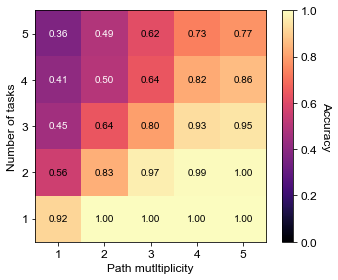


Accuracy Matrix (rows=var1, cols=var2, averaged over var3):
[[0.91584 0.99832 0.99888 0.9992  0.99944]
 [0.55728 0.83304 0.9676  0.99448 0.99576]
 [0.45008 0.63904 0.79928 0.93344 0.94624]
 [0.40744 0.49728 0.6404  0.82072 0.86288]
 [0.36448 0.48984 0.61512 0.73376 0.7748 ]]


In [23]:
# Plot heatmap
import pickle
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Arial'

import numpy as np
fs = 12
fig, ax = plt.subplots(1, 1, figsize=(5, 4))

# Accuracy heatmap
im1 = ax.imshow(accuracy_matrix, cmap='magma', vmin=0.0, vmax=1, origin='lower')
ax.set_xticks(range(len(var2_list)))
ax.set_xticklabels(var2_list, fontsize=fs)
ax.set_yticks(range(len(var1_list)))
ax.set_yticklabels(var1_list, fontsize=fs)
ax.set_xlabel('Path mutltiplicity', fontsize=fs)
ax.set_ylabel('Number of tasks', fontsize=fs)

cbar = plt.colorbar(im1, ax=ax)
cbar.ax.set_ylabel('Accuracy', rotation=-90, va="bottom", fontsize=fs)
cbar.ax.tick_params(labelsize=fs)

# Add text annotations
for i in range(len(var1_list)):
    for j in range(len(var2_list)):
        val = accuracy_matrix[i, j]
        if not np.isnan(val):
            text_color = 'white' if val < 0.5 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=text_color, fontsize=fs-2)

plt.tight_layout()
plt.show()

# Print summary table
print("\nAccuracy Matrix (rows=var1, cols=var2, averaged over var3):")
print(accuracy_matrix)